# Block Encoding of FEM Operators: Circuits, Baselines, and Gate Counts

### Companion notebook to *Structured Block Encoding of the Finite Element Elasticity Operator*

---

This notebook covers the parts of the paper that live **below** the algebra: the
general-purpose baselines the method is measured against, the Qiskit circuits,
and what those circuits actually cost once compiled.

The algebra itself — how each operator decomposes, how boundary conditions
enter, why $\alpha$ behaves as it does — is worked out example by example in
three companion notebooks that need nothing but NumPy:

| Notebook | Content |
|---|---|
| `AppendixA_1D_Poisson.ipynb` | shifts, reflections, the three boundary treatments, the block encoding built by hand |
| `AppendixB_2D_Poisson.ipynb` | Kronecker merging, boundary treatment **by direction**, term counts as a product |
| `AppendixC_2D_Elasticity.ipynb` | the DOF qubit, the $\{I,Z,X\}$ components, the fourth component $iY$, the cantilever |

Start there if you want to understand the construction. Come here for
circuits and numbers.

**What this notebook establishes**

- General-purpose encoders cost $\alpha = 2^m$ (FABLE) or $\mathcal{O}(4^s)$ terms (Pauli); shift decomposition holds $L$ and $\alpha$ constant in $N$
- Qiskit circuits for Poisson and elasticity, verified against the classical operator to machine precision
- $A|x\rangle$ recovered by statevector simulation, with the post-selection success probability
- **Compiled two-qubit gate counts**, and the grid size at which structure starts paying
- An honest account of where this package's circuits differ from the paper's design

**Prerequisites:** `numpy`, `matplotlib`, `qiskit`, `qiskit-aer`, and this package.

```bash
pip install -e .
pip install numpy matplotlib qiskit qiskit-aer
```

> **Terminology.** Earlier drafts of this notebook called the method "pattern
> compression" and the $\{I,Z,X\}$ split "DOF channels". The paper uses the
> standard terms **shift decomposition** and **Pauli components**; this notebook
> follows the paper.

In [29]:
import time
import numpy as np
import matplotlib.pyplot as plt

from pyblockencode.operators import (
    poisson_1d_fdm, poisson_1d_fem,
    poisson_2d_fdm, poisson_2d_fem,
    poisson_3d_fdm, poisson_3d_fem,
    elasticity_q4,
)
from pyblockencode.poisson_pattern import PoissonPatternEncoding
from pyblockencode.elasticity_pattern import ElasticityPatternEncoding
from pyblockencode.qiskit_encoding import (
    PauliBlockEncoding, PoissonCircuit, ElasticityCircuit, apply_Ax,
)

import qiskit
print(f"qiskit {qiskit.__version__} — imports OK")

qiskit 2.4.2 — imports OK


## 1  Why structure matters

Quantum linear-algebra algorithms (HHL, QSVT, qubitization) do not act on a
matrix directly. They need a unitary $\mathcal{U}$ on $a + s$ qubits with

$$\mathbf{A} = \alpha\,\bigl(\langle 0|^{\otimes a}\otimes I\bigr)\,
   \mathcal{U}\,\bigl(|0\rangle^{\otimes a}\otimes I\bigr),$$

so $\mathbf{A}/\alpha$ occupies the top-left block. The subnormalization
$\alpha \geq \|\mathbf{A}\|$ enters downstream runtime **linearly**, so it
matters as much as gate count.

A general-purpose encoder works from raw matrix entries and pays for it.
Kuklinski et al. make the negative result precise: efficient block encodings
*require* structure. The operators of computational mechanics have it — they
are banded, built from a few repeated entries, and separable into Kronecker
factors.

**Shift decomposition** exploits exactly that: each 1D factor becomes a short
sum of cyclic shifts $S_c$, $S_c^\dagger$, giving $L = \mathcal{O}(1)$ terms and
$\alpha = \mathcal{O}(1)$, both independent of $N$.

## 2  Baselines: what "general purpose" costs

Two reference points. FABLE encodes any matrix from its entries at
$\alpha = 2^m$ — the subnormalization alone grows with the grid. Pauli-basis
expansion keeps $\alpha$ reasonable but the **term count** grows.

In [30]:
print(f"{'m':>3}{'N=2^m':>7}{'FABLE alpha = N':>18}{'shift-decomp alpha':>20}{'ratio':>9}")
print("-" * 60)
for m in range(1, 9):
    N = 2 ** m
    a_shift = PoissonPatternEncoding(m=m, dim=1, disc='fdm').alpha
    print(f"{m:>3}{N:>7}{float(N):>18.1f}{a_shift:>20.3f}{N/a_shift:>8.1f}x")
print("\nShift decomposition holds alpha = 4.000 at every grid size.")

# Pauli term count for the same operator
print(f"\n{'m':>3}{'N':>6}{'Pauli terms':>14}{'shift terms':>14}")
print("-" * 40)
from qiskit.quantum_info import SparsePauliOp
for m in range(1, 6):
    K = poisson_1d_fdm(m=m)
    npauli = len(SparsePauliOp.from_operator(K).coeffs)
    print(f"{m:>3}{2**m:>6}{npauli:>14}{PoissonPatternEncoding(m=m,dim=1,disc='fdm').num_terms:>14}")

  m  N=2^m   FABLE alpha = N  shift-decomp alpha    ratio
------------------------------------------------------------
  1      2               2.0               4.000     0.5x
  2      4               4.0               4.000     1.0x
  3      8               8.0               4.000     2.0x
  4     16              16.0               4.000     4.0x
  5     32              32.0               4.000     8.0x
  6     64              64.0               4.000    16.0x
  7    128             128.0               4.000    32.0x
  8    256             256.0               4.000    64.0x

Shift decomposition holds alpha = 4.000 at every grid size.

  m     N   Pauli terms   shift terms
----------------------------------------
  1     2             2             3
  2     4             4             3
  3     8             8             3
  4    16            16             3
  5    32            32             3


## 3  The 1D building blocks

Everything is assembled from three 1D factors. Appendix A works these out in
full, including the boundary treatments; here we only need their shift
expansions.

| Factor | Matrix | Shift expansion | $\alpha$ |
|---|---|---|---|
| Stiffness $\mathbf{K}_1$ | $\mathrm{tridiag}(-1,2,-1)$ | $2I - S_c - S_c^\dagger$ | 4 |
| Mass $\mathbf{M}_1$ | $\tfrac16\mathrm{tridiag}(1,4,1)$ | $\tfrac46 I + \tfrac16 S_c + \tfrac16 S_c^\dagger$ | 1 |
| Gradient $\mathbf{G}_1$ | $\tfrac12\mathrm{tridiag}(-1,0,1)$ | $\tfrac12 S_c^\dagger - \tfrac12 S_c$ | 1 |

The shifts are cyclic, so these expansions give the *periodic* operator. Turning
that into a boundary-value problem is the subject of Section 12 below — the
package and the paper currently do it differently.

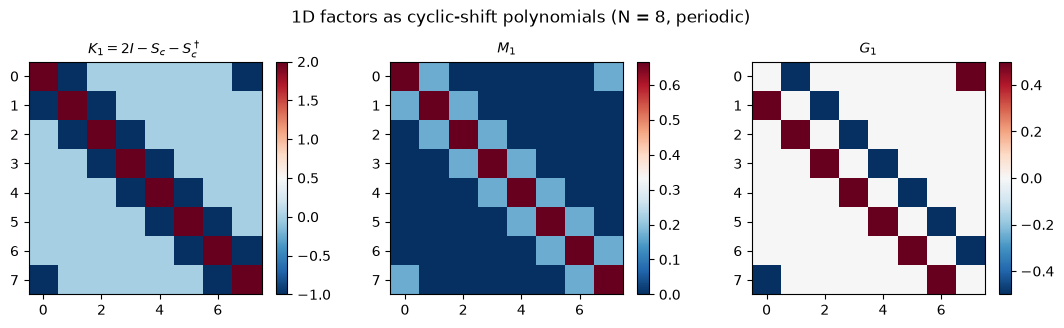

K1: alpha = 4.0,  corner entry (wrap) = -1.0000
M1: alpha = 1.0,  corner entry (wrap) = +0.1667
G1: alpha = 1.0,  corner entry (wrap) = +0.5000


In [31]:
def cyclic_shift(N):
    S = np.eye(N, k=1); S[-1, 0] = 1.0
    return S

m, N = 3, 8
I, Sc = np.eye(N), cyclic_shift(N); Scd = Sc.T
K1, M1, G1 = 2*I - Sc - Scd, (4*I + Sc + Scd)/6, (Scd - Sc)/2

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
for ax, A, t in zip(axes, [K1, M1, G1],
                    [r'$K_1 = 2I - S_c - S_c^\dagger$',
                     r'$M_1$', r'$G_1$']):
    im = ax.imshow(A, cmap='RdBu_r'); ax.set_title(t, fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle(f'1D factors as cyclic-shift polynomials (N = {N}, periodic)')
plt.tight_layout(); plt.show()

for lbl, A, a in [('K1', K1, 4.0), ('M1', M1, 1.0), ('G1', G1, 1.0)]:
    print(f"{lbl}: alpha = {a},  corner entry (wrap) = {A[0, -1]:+.4f}")

## 4  Poisson in one, two and three dimensions

Separability means the 2D and 3D operators merge onto products of the same 1D
basis. Appendix B does the 2D case by hand; 3D is included here because the
companion notebooks stop at two.

In [32]:
rows = []
for dim in (1, 2, 3):
    for disc in ('fdm', 'fem'):
        e = PoissonPatternEncoding(m=2, dim=dim, disc=disc)
        r = e.verify()
        rows.append((f"{dim}D {disc.upper()}", e.num_terms, e.alpha,
                     e.num_qubits, r['block_encoding_rel_err']))
print(f"{'operator':<12}{'L':>5}{'alpha':>10}{'qubits':>9}{'verify err':>14}")
print("-" * 52)
for r in rows:
    print(f"{r[0]:<12}{r[1]:>5}{r[2]:>10.4f}{r[3]:>9}{r[4]:>14.2e}")
    assert r[4] < 1e-12

operator        L     alpha   qubits    verify err
----------------------------------------------------
1D FDM          3    4.0000        5      2.99e-16
1D FEM          3    4.0000        5      2.99e-16
2D FDM          5    8.0000        8      2.22e-16
2D FEM          9    5.3333        9      3.69e-16
3D FDM          7   12.0000       10      2.79e-16
3D FEM         21    5.3333       12      3.35e-16


## 5  Elasticity: the 17-term LCU

The $2\times2$ displacement block collapses onto a single DOF qubit,

$$\mathbf{K} = \frac{\mathbf{K}_{xx}+\mathbf{K}_{yy}}{2}\otimes I
             + \frac{\mathbf{K}_{xx}-\mathbf{K}_{yy}}{2}\otimes Z
             + \mathbf{K}_{xy}\otimes X,$$

three **Pauli components** on the same nine shift offsets as 2D Poisson, giving
17 terms rather than 9. Appendix C derives this and shows a fourth component
$iY$ appearing once a boundary is opened.

In [33]:
e = ElasticityPatternEncoding(m=2, E=1.0, nu=0.3)
print(f"L = {e.num_terms}, alpha = {e.alpha:.4f}, qubits = {e.num_qubits}")
print(f"verify: {e.verify()['block_encoding_rel_err']:.2e}\n")

comp_of = {'I': 'I  (isotropic)', 'Z': 'Z  (anisotropy)', 'X': 'X  (shear)'}
for k, c in sorted(e.lcu_terms().items()):
    print(f"  {str(k):<22} {c:+.6f}   {comp_of.get(k[-1], k[-1])}")

print("\nclosed form alpha(nu) = E(33+nu) / (6(1-nu^2)):")
for nu in (0.0, 0.3, 0.45):
    a = ElasticityPatternEncoding(m=2, E=1.0, nu=nu).alpha
    print(f"  nu={nu:<5} alpha={a:.6f}   closed form={(33+nu)/(6*(1-nu**2)):.6f}")
    assert abs(a - (33+nu)/(6*(1-nu**2))) < 1e-10

L = 17, alpha = 6.0989, qubits = 11
verify: 3.79e-16

  ('I', 'I', 'I')        +1.978022   I  (isotropic)
  ('I', 'Sc', 'I')       -0.247253   I  (isotropic)
  ('I', 'Sc', 'Z')       +0.357143   Z  (anisotropy)
  ('I', 'Scd', 'I')      -0.247253   I  (isotropic)
  ('I', 'Scd', 'Z')      +0.357143   Z  (anisotropy)
  ('Sc', 'I', 'I')       -0.247253   I  (isotropic)
  ('Sc', 'I', 'Z')       -0.357143   Z  (anisotropy)
  ('Sc', 'Sc', 'I')      -0.247253   I  (isotropic)
  ('Sc', 'Sc', 'X')      -0.178571   X  (shear)
  ('Sc', 'Scd', 'I')     -0.247253   I  (isotropic)
  ('Sc', 'Scd', 'X')     +0.178571   X  (shear)
  ('Scd', 'I', 'I')      -0.247253   I  (isotropic)
  ('Scd', 'I', 'Z')      -0.357143   Z  (anisotropy)
  ('Scd', 'Sc', 'I')     -0.247253   I  (isotropic)
  ('Scd', 'Sc', 'X')     +0.178571   X  (shear)
  ('Scd', 'Scd', 'I')    -0.247253   I  (isotropic)
  ('Scd', 'Scd', 'X')    -0.178571   X  (shear)

closed form alpha(nu) = E(33+nu) / (6(1-nu^2)):
  nu=0.0   alpha=5.500000

## 6  How tight is $\alpha$? — and a cautionary tale

An earlier version of this notebook measured $\alpha / \|\mathbf{K}\|_2$ at
$m = 2$ (a $4\times4$ node grid) and reported $\approx 1.6$. That number
reached the paper and was **wrong** — not because the ratio was mis-measured,
but because $\|\mathbf{K}\|_2$ has not converged on so small a grid.

Sweeping $N$ shows the ratio settling near $1.39$. The lesson is worth keeping
visible: a tightness ratio quoted at one small grid size is not a property of
the encoding.

  m    N    alpha   ||K||_2  ||K||_inf  a/||K||_2  a/||K||_inf
--------------------------------------------------------------
  1    2   6.0989    3.1181     3.1181     1.9559       1.9559
  2    4   6.0989    3.7972     5.1099     1.6062       1.1935
  3    8   6.0989    4.1955     5.1099     1.4537       1.1935
  4   16   6.0989    4.3381     5.1099     1.4059       1.1935
  5   32   6.0989    4.3802     5.1099     1.3924       1.1935


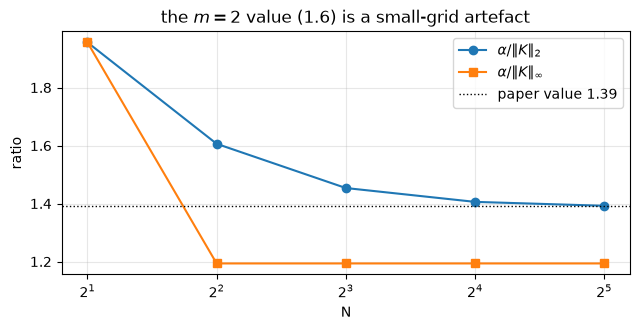


at m=2 : alpha/||K||_2 = 1.606   <- the number that reached the paper
at m=5 : alpha/||K||_2 = 1.392   <- converged
alpha/||K||_inf is already at its limit at every N: it does not depend on the grid.


In [34]:
ms = list(range(1, 6))
print(f"{'m':>3}{'N':>5}{'alpha':>9}{'||K||_2':>10}{'||K||_inf':>11}"
      f"{'a/||K||_2':>11}{'a/||K||_inf':>13}")
print("-" * 62)
r2, rinf = [], []
for m_ in ms:
    enc = ElasticityPatternEncoding(m=m_, E=1.0, nu=0.3)
    K = enc.target()
    a = enc.alpha
    n2, ninf = np.linalg.norm(K, 2), np.abs(K).sum(1).max()
    r2.append(a/n2); rinf.append(a/ninf)
    print(f"{m_:>3}{2**m_:>5}{a:>9.4f}{n2:>10.4f}{ninf:>11.4f}"
          f"{a/n2:>11.4f}{a/ninf:>13.4f}")

fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.plot([2**m_ for m_ in ms], r2, 'o-', label=r'$\alpha/\|K\|_2$')
ax.plot([2**m_ for m_ in ms], rinf, 's-', label=r'$\alpha/\|K\|_\infty$')
ax.axhline(1.39, color='k', ls=':', lw=1, label='paper value 1.39')
ax.set_xscale('log', base=2); ax.set_xlabel('N'); ax.set_ylabel('ratio')
ax.set_title(r'the $m=2$ value (1.6) is a small-grid artefact')
ax.legend(); ax.grid(alpha=.3); plt.tight_layout(); plt.show()

print(f"\nat m=2 : alpha/||K||_2 = {r2[1]:.3f}   <- the number that reached the paper")
print(f"at m=5 : alpha/||K||_2 = {r2[-1]:.3f}   <- converged")
print("alpha/||K||_inf is already at its limit at every N: it does not depend on the grid.")

## 7  $L$ and $\alpha$ are constant in $N$

The central claim, checked across grid sizes for every operator.

In [35]:
cases = [
    ('Poisson 1D FDM', lambda m: PoissonPatternEncoding(m=m, dim=1, disc='fdm')),
    ('Poisson 1D FEM', lambda m: PoissonPatternEncoding(m=m, dim=1, disc='fem')),
    ('Poisson 2D FDM', lambda m: PoissonPatternEncoding(m=m, dim=2, disc='fdm')),
    ('Poisson 2D FEM', lambda m: PoissonPatternEncoding(m=m, dim=2, disc='fem')),
    ('Poisson 3D FDM', lambda m: PoissonPatternEncoding(m=m, dim=3, disc='fdm')),
    ('Poisson 3D FEM', lambda m: PoissonPatternEncoding(m=m, dim=3, disc='fem')),
    ('Elasticity 2D',  lambda m: ElasticityPatternEncoding(m=m, nu=0.3)),
]
ms = list(range(1, 9))
print(f"{'operator':<18}" + "".join(f"{'m=%d'%m:>7}" for m in ms))
print("-" * (18 + 7*len(ms)))
print("L:")
for lbl, f in cases:
    Ls = [f(m).num_terms for m in ms]
    print(f"  {lbl:<16}" + "".join(f"{L:>7}" for L in Ls))
    assert len(set(Ls)) == 1
print("alpha:")
for lbl, f in cases:
    al = [f(m).alpha for m in ms]
    print(f"  {lbl:<16}" + "".join(f"{a:>7.3f}" for a in al))
    assert max(al) - min(al) < 1e-12
print("\nEvery row is constant. Doubling the resolution adds a qubit, not a term.")

operator              m=1    m=2    m=3    m=4    m=5    m=6    m=7    m=8
--------------------------------------------------------------------------
L:
  Poisson 1D FDM        3      3      3      3      3      3      3      3
  Poisson 1D FEM        3      3      3      3      3      3      3      3
  Poisson 2D FDM        5      5      5      5      5      5      5      5
  Poisson 2D FEM        9      9      9      9      9      9      9      9
  Poisson 3D FDM        7      7      7      7      7      7      7      7
  Poisson 3D FEM       21     21     21     21     21     21     21     21
  Elasticity 2D        17     17     17     17     17     17     17     17
alpha:
  Poisson 1D FDM    4.000  4.000  4.000  4.000  4.000  4.000  4.000  4.000
  Poisson 1D FEM    4.000  4.000  4.000  4.000  4.000  4.000  4.000  4.000
  Poisson 2D FDM    8.000  8.000  8.000  8.000  8.000  8.000  8.000  8.000
  Poisson 2D FEM    5.333  5.333  5.333  5.333  5.333  5.333  5.333  5.333
  Poisson 3D FD

## 8  Qubit scaling

$L$ and $\alpha$ are fixed; the qubit count grows linearly in $m$, as it must.

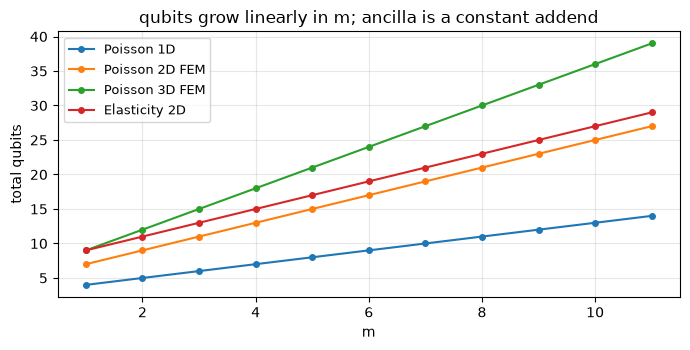

  Poisson 1D       qubits = m + 3
  Poisson 2D FEM   qubits = 2m + 5
  Poisson 3D FEM   qubits = 3m + 6
  Elasticity 2D    qubits = 2m + 7


In [36]:
ms_q = list(range(1, 12))
qc_cases = [
    ('Poisson 1D', lambda m: PoissonPatternEncoding(m=m, dim=1, disc='fdm')),
    ('Poisson 2D FEM', lambda m: PoissonPatternEncoding(m=m, dim=2, disc='fem')),
    ('Poisson 3D FEM', lambda m: PoissonPatternEncoding(m=m, dim=3, disc='fem')),
    ('Elasticity 2D', lambda m: ElasticityPatternEncoding(m=m, nu=0.3)),
]
fig, ax = plt.subplots(figsize=(7, 3.6))
for lbl, f in qc_cases:
    ax.plot(ms_q, [f(m).num_qubits for m in ms_q], 'o-', ms=4, label=lbl)
ax.set_xlabel('m'); ax.set_ylabel('total qubits'); ax.legend(fontsize=9)
ax.set_title('qubits grow linearly in m; ancilla is a constant addend')
ax.grid(alpha=.3); plt.tight_layout(); plt.show()

for lbl, f in qc_cases:
    s = f(2).num_qubits - f(1).num_qubits
    coef = "m" if s == 1 else f"{s}m"
    print(f"  {lbl:<16} qubits = {coef} + {f(1).num_qubits - s}")

## 9  Resource summary

Figures for the essential-boundary elasticity encoding, matching Table 3 of the
paper. Note the two corrections relative to earlier versions of this notebook:
$\alpha/\|\mathbf{K}\|_2 \approx 1.39$ (Section 6), and the boundary correction
is carried by **reflections adjoined to the unitary set**, not by a flag
ancilla — see Section 12.

In [37]:
nu = 0.3
e = ElasticityPatternEncoding(m=3, E=1.0, nu=nu)
print("Elasticity Q4 block encoding, essential boundary conditions (E = 1)")
print("-" * 62)
print(f"  {'System qubits':<28} 2m + 1")
print(f"  {'PREP ancilla':<28} ceil(log2 49) = 6")
print(f"  {'Total qubits':<28} 2m + 7")
print(f"  {'LCU terms L':<28} 17 periodic / 49 essential / 109 traction-free")
print(f"  {'alpha (nu=0.00)':<28} {ElasticityPatternEncoding(m=3,nu=0.0).alpha:.4f}")
print(f"  {'alpha (nu=0.30)':<28} {e.alpha:.4f}")
print(f"  {'alpha (nu=0.45)':<28} {ElasticityPatternEncoding(m=3,nu=0.45).alpha:.4f}")
print(f"  {'alpha / ||K||_2':<28} ~ 1.39  (converged; see Section 6)")
print(f"  {'information eff. eta':<28} ~ 0.72")
print(f"  {'Boundary conditions':<28} reflections adjoined to the unitary set")
print(f"  {'Verification error':<28} ~ 1e-16")

Elasticity Q4 block encoding, essential boundary conditions (E = 1)
--------------------------------------------------------------
  System qubits                2m + 1
  PREP ancilla                 ceil(log2 49) = 6
  Total qubits                 2m + 7
  LCU terms L                  17 periodic / 49 essential / 109 traction-free
  alpha (nu=0.00)              5.5000
  alpha (nu=0.30)              6.0989
  alpha (nu=0.45)              6.9906
  alpha / ||K||_2              ~ 1.39  (converged; see Section 6)
  information eff. eta         ~ 0.72
  Boundary conditions          reflections adjoined to the unitary set
  Verification error           ~ 1e-16


## 10  Comparison with prior work

Condensed from the paper's literature review. The dividing line is whether the
term count is constant in $N$.

| Work | Paradigm | Elasticity? | Const. terms? | Depth | Key gap |
|---|---|---|---|---|---|
| Rémond et al. | VQA / NISQ Pauli meas. | Yes (Q4 full) | No — $\mathcal{O}(n_xn_y)$ | N/A | not a block encoding |
| Danz et al. | arithmetic value oracle | No (1D scalar) | No — $\mathcal{O}(r^2)$/entry | $\mathcal{O}(r^2)$ | scalar, 1D |
| Qu-FEM | fault-tolerant LCU + shifts | No (scalar) | Yes (scalar) | $\mathcal{O}(n)$ | vector elasticity out of scope |
| Lu et al. | VQLS; Pauli and SVD LCU | No (scalar CFD) | No (Pauli); 2 (SVD) | $\mathcal{O}(4^s)$/term | SVD factors lack efficient circuits |
| Arora et al. | element QSD + permute | Yes (Q4 element) | No — $\mathcal{O}(N)$ depth | linear in $N$ | encodes element, not global |
| Kharazi et al. | shift LCU, FDM | No (scalar) | Yes (scalar) | $\mathcal{O}(n)$ | scalar Laplacian only |
| Cobble, Unitaria | compilers; compose encodings | N/A | N/A | inherits | need the basic encoding as input |
| **This work** | **shift-decomposition LCU** | **Yes, Q4 full** | **Yes — 17/49/109** | $\mathcal{O}(m)$ | — |

The last column of the paper's version carries the full discussion. Two points
worth restating: Cobble and Unitaria are *complementary*, consuming exactly the
kind of object this work produces; and the singular-value dilation used by Lu
et al. reaches $L = 2$ at optimal $\alpha$ for any matrix, but with dense
unstructured factors that have no efficient circuit — minimal term count is not
automatically a bargain.

---
## 11  Circuits

Everything above works with dense NumPy matrices. This section generates actual
Qiskit circuits and verifies them by simulation.

**Convention.** System register declared first (LSB), ancilla second (MSB), so
$\mathbf{A}/\alpha$ sits in the contiguous top-left corner:

```python
QuantumCircuit(qr_sys, qr_flag, qr_anc)     # system LSB, ancilla MSB
alpha * Operator(qc).data[:N0, :N0]  ==  A
```

### 11.1  Pauli LCU — the general-purpose baseline

In [38]:
K4 = poisson_1d_fdm(m=2)
pbe = PauliBlockEncoding(K4)
r = pbe.verify()
print(f"Pauli LCU:  terms = {pbe.num_terms},  alpha = {pbe.alpha:.4f}, "
      f"qubits = {pbe.circuit().num_qubits}")
print(f"  block encoding rel err = {r['block_encoding_rel_err']:.2e}")
print(f"  unitarity err          = {r['unitarity_err']:.2e}")
assert r['block_encoding_rel_err'] < 1e-12

Pauli LCU:  terms = 4,  alpha = 4.0000, qubits = 4
  block encoding rel err = 9.17e-16
  unitarity err          = 6.20e-15


### 11.2  Poisson circuits — shift decomposition

In [39]:
for lbl, kw in [('1D FDM', dict(m=2, dim=1, disc='fdm')),
                ('1D FEM', dict(m=2, dim=1, disc='fem')),
                ('2D FDM', dict(m=2, dim=2, disc='fdm'))]:
    t0 = time.time()
    pc = PoissonCircuit(**kw); r = pc.verify()
    print(f"Poisson {lbl}:  L = {pc.num_terms}, alpha = {pc.alpha:.4f}, "
          f"qubits = {pc.num_qubits}")
    print(f"   ||alpha*U[:N0,:N0] - K|| / ||K|| = {r['block_encoding_rel_err']:.2e}"
          f"   ({time.time()-t0:.0f}s)")
    assert r['block_encoding_rel_err'] < 1e-11

Poisson 1D FDM:  L = 3, alpha = 4.0000, qubits = 5
   ||alpha*U[:N0,:N0] - K|| / ||K|| = 2.80e-15   (0s)
Poisson 1D FEM:  L = 3, alpha = 4.0000, qubits = 5
   ||alpha*U[:N0,:N0] - K|| / ||K|| = 2.80e-15   (0s)
Poisson 2D FDM:  L = 5, alpha = 8.0000, qubits = 8
   ||alpha*U[:N0,:N0] - K|| / ||K|| = 1.13e-13   (10s)


### 11.3  Elasticity circuit

Building the full $2^{10}$ unitary and comparing it to the classical operator.
This cell takes a few minutes.

In [40]:
t0 = time.time()
ec = ElasticityCircuit(m=1, E=1.0, nu=0.3)
print(f"Elasticity Q4, m=1, nu=0.3:  L = {ec.num_terms}, alpha = {ec.alpha:.4f}, "
      f"qubits = {ec.num_qubits}")
r = ec.verify()
print(f"  ||alpha*U[:N0,:N0] - K|| / ||K|| = {r['block_encoding_rel_err']:.2e}")
print(f"  ||U^dag U - I||                  = {r['unitarity_err']:.2e}")
print(f"  ({time.time()-t0:.0f}s)")
assert r['block_encoding_rel_err'] < 1e-10

Elasticity Q4, m=1, nu=0.3:  L = 17, alpha = 6.0989, qubits = 9
  ||alpha*U[:N0,:N0] - K|| / ||K|| = 4.05e-13
  ||U^dag U - I||                  = 2.60e-11
  (224s)


### 11.4  Recovering $A|x\rangle$ by simulation

Prepare $|x\rangle$ on the system register, run the circuit, post-select the
ancilla on $|0\rangle$, rescale by $\alpha$:

$$\mathcal{U}\,\bigl(|x\rangle_{\rm sys}\otimes|0\rangle_{\rm anc}\bigr)
 = \tfrac1\alpha\, A|x\rangle\,|0\rangle_{\rm anc} + |\text{garbage}\rangle .$$

The success probability $p = \|A|x\rangle\|^2/\alpha^2$ is what post-selection
costs, and it is bounded by $\|A\|^2/\alpha^2$ — which is exactly why the
tightness of $\alpha$ in Section 6 matters in practice.

Poisson 1D  : max rel err = 8.46e-15,  p in [0.0256, 0.1654]
Elasticity  : max rel err = 4.28e-13,  p in [0.0406, 0.0690]


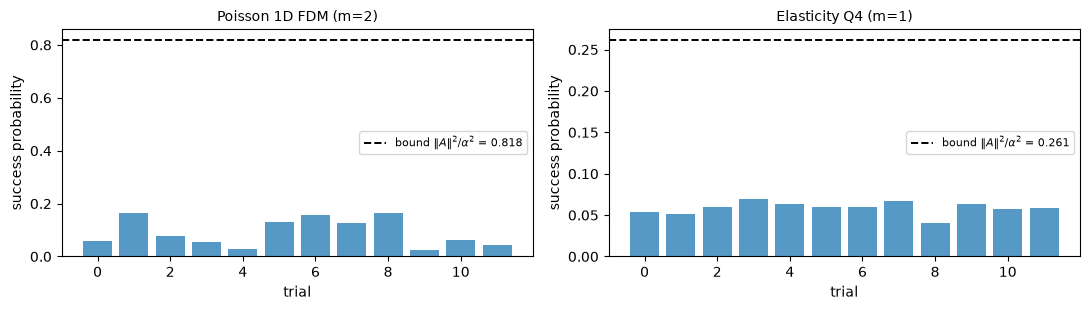

In [41]:
rng = np.random.default_rng(0)

def ax_trials(enc, n_dof, n=12):
    errs, ps = [], []
    for _ in range(n):
        x = rng.random(n_dof) + 1j*rng.random(n_dof); x /= np.linalg.norm(x)
        r = apply_Ax(enc, x)
        errs.append(r['rel_err']); ps.append(r['success_prob'])
    return np.array(errs), np.array(ps)

pc = PoissonCircuit(m=2, dim=1, disc='fdm')
ec = ElasticityCircuit(m=1, E=1.0, nu=0.3)
e_p, p_p = ax_trials(pc, 4)
e_e, p_e = ax_trials(ec, 2 * ec.enc.N**2)

print(f"Poisson 1D  : max rel err = {e_p.max():.2e},  p in "
      f"[{p_p.min():.4f}, {p_p.max():.4f}]")
print(f"Elasticity  : max rel err = {e_e.max():.2e},  p in "
      f"[{p_e.min():.4f}, {p_e.max():.4f}]")
assert e_p.max() < 1e-10 and e_e.max() < 1e-10

bound_p = np.linalg.norm(pc.target(), 2)**2 / pc.alpha**2
bound_e = np.linalg.norm(ec.target(), 2)**2 / ec.alpha**2
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
for ax, ps, b, t in [(axes[0], p_p, bound_p, 'Poisson 1D FDM (m=2)'),
                     (axes[1], p_e, bound_e, 'Elasticity Q4 (m=1)')]:
    ax.bar(range(len(ps)), ps, alpha=.75)
    ax.axhline(b, color='k', ls='--', lw=1.4,
               label=r'bound $\|A\|^2/\alpha^2$ = %.3f' % b)
    ax.set_xlabel('trial'); ax.set_ylabel('success probability')
    ax.set_title(t, fontsize=10); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### 11.5  Compiled gate counts: where structure starts paying

This is the comparison an earlier version of this notebook got wrong by
stopping at $N = 4$. At that size the general-purpose Pauli encoder genuinely
*is* cheaper — the structured circuit carries fixed overhead that a $4\times4$
matrix never amortizes. Reporting only that point makes the method look five
times worse than the baseline it beats.

Sweeping the grid instead:

     N    Pauli CX   shift-decomp CX    ratio
----------------------------------------------
     4          38               346     0.11
     8         282               954     0.30
    16        1986              2802     0.71
    32       11592              6618     1.75
    64       47406             12850     3.69
   128      177260             22770     7.78


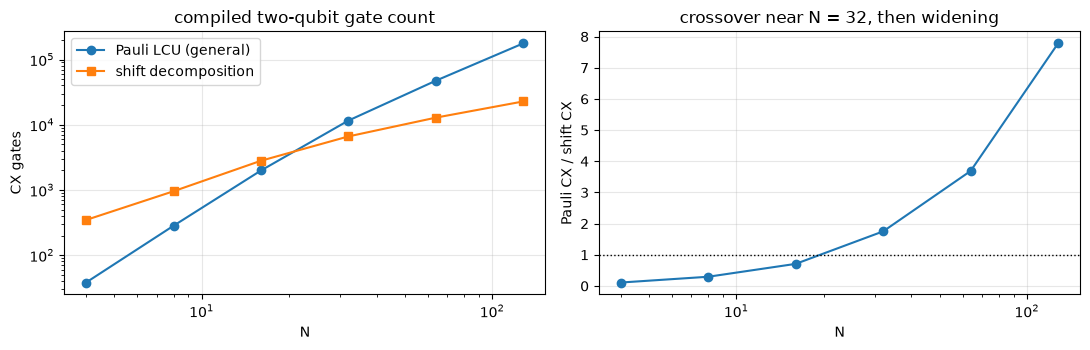


Per added qubit, Pauli CX grows by ~7x at small N settling toward ~4x;
shift decomposition starts near 2.9x and is still falling — 1.8x at N=128.


In [42]:
from qiskit import transpile

def cx_count(qc, reps=6):
    qt = transpile(qc.decompose(reps=reps), basis_gates=['u', 'cx'],
                   optimization_level=1)
    return qc.num_qubits, qt.depth(), qt.count_ops().get('cx', 0)

sweep = []
print(f"{'N':>6}{'Pauli CX':>12}{'shift-decomp CX':>18}{'ratio':>9}")
print("-" * 46)
for m_ in range(2, 8):
    _, _, cx_pauli = cx_count(PauliBlockEncoding(poisson_1d_fdm(m=m_)).circuit())
    _, _, cx_shift = cx_count(PoissonCircuit(m=m_, dim=1, disc='fdm').circuit())
    sweep.append((2**m_, cx_pauli, cx_shift))
    print(f"{2**m_:>6}{cx_pauli:>12}{cx_shift:>18}{cx_pauli/cx_shift:>9.2f}")

Ns = [s[0] for s in sweep]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.6))
a1.loglog(Ns, [s[1] for s in sweep], 'o-', label='Pauli LCU (general)')
a1.loglog(Ns, [s[2] for s in sweep], 's-', label='shift decomposition')
a1.set_xlabel('N'); a1.set_ylabel('CX gates'); a1.legend(); a1.grid(alpha=.3)
a1.set_title('compiled two-qubit gate count')
a2.semilogx(Ns, [s[1]/s[2] for s in sweep], 'o-')
a2.axhline(1.0, color='k', ls=':', lw=1)
a2.set_xlabel('N'); a2.set_ylabel('Pauli CX / shift CX')
a2.set_title('crossover near N = 32, then widening'); a2.grid(alpha=.3)
plt.tight_layout(); plt.show()

print("\nPer added qubit, Pauli CX grows by ~7x at small N settling toward ~4x;")
print("shift decomposition starts near 2.9x and is still falling — 1.8x at N=128.")

### 11.6  What this circuit layer is — and is not

The gate counts above are honest measurements of *this package's* circuits, and
those circuits are **not** the SELECT described in Section 7.3 of the paper.

The paper's SELECT reads the ancilla index as **fields** — shift exponents,
reflection flags, a Pauli index — and applies a constant number of parameterized
operations: two adders, two reflections, one Pauli, independent of $L$. That is
what gives $\mathcal{O}(m)$ depth.

`qiskit_encoding.py` instead builds one fully-controlled block per LCU term:

```python
for i, key in enumerate(labels):
    ctrl_gate = sel_circ.to_gate().control(na_prep, ctrl_state=format(i, ...))
```

This is the textbook LCU harness. It is correct — everything above verifies to
machine precision — but its cost is $\mathcal{O}(L)$ controlled blocks, and the
measured depth reflects that, not the paper's design.

In [43]:
print(f"{'m':>3}{'N':>6}{'qubits':>8}{'depth':>10}{'CX':>10}{'CX ratio':>10}")
print("-" * 48)
prev = None
for m_ in range(1, 5):
    qc = ElasticityCircuit(m=m_, E=1.0, nu=0.3).circuit()
    q, d, cx = cx_count(qc)
    rs = f"{cx/prev:.2f}" if prev else "--"
    print(f"{m_:>3}{2**m_:>6}{q:>8}{d:>10}{cx:>10}{rs:>10}")
    prev = cx

print("\nCX grows by roughly 2.5-3x per added qubit per dimension.")
print("An O(m)-depth SELECT would grow linearly in m instead.")
print("Implementing the adder-based SELECT is the open engineering task;")
print("until then, do not quote these gate counts as evidence for the")
print("paper's polylogarithmic-depth claim.")

  m     N  qubits     depth        CX  CX ratio
------------------------------------------------
  1     2      10     12785      8644        --
  2     4      12     71633     48964      5.66
  3     8      14    192305    132292      2.70
  4    16      16    576593    394372      2.98

CX grows by roughly 2.5-3x per added qubit per dimension.
An O(m)-depth SELECT would grow linearly in m instead.
Implementing the adder-based SELECT is the open engineering task;
until then, do not quote these gate counts as evidence for the
paper's polylogarithmic-depth claim.


---
## 12  Where the package and the paper differ

Worth stating plainly, so nobody reads this notebook as the paper's final word.

**Boundary conditions.** The package imposes Dirichlet conditions with a
**flag ancilla** that detects wrap-around and shunts it out of the encoded
block: 17 terms, 5 PREP qubits + 1 flag. The paper adopts the **reflection**
construction of Kharazi et al., which adjoins $R_A = I - 2\sum_{j\in A}|j\rangle\langle j|$
to the unitary set: 49 terms, 6 PREP qubits, **no flag**. Both total $2m+7$
qubits, so the headline number is unchanged and the difference is easy to miss.
Appendices A and B work the reflection construction in full.

**Natural boundary conditions.** The package has none. The paper's Section 6.3
gives the traction-free operator, which needs a fourth Pauli component $iY$
(109 terms), and Section 6.5 gives mixed conditions. Appendix C demonstrates
the fourth component appearing.

**SELECT.** Section 11.6 above.

| | package today | paper |
|---|---|---|
| Dirichlet | flag ancilla, $L=17$ | reflections, $L=49$ |
| Ancilla split | 5 PREP + 1 flag | 6 PREP, no flag |
| Traction-free | — | $L=109$, four components |
| Mixed conditions | — | Section 6.5 |
| SELECT | one controlled block per term | field-decoded, $\mathcal{O}(m)$ |

None of this affects the algebra in Sections 1–10, which is verified
independently and matches the paper.

## 13  Summary

| Operator | $L$ | $\alpha$ | qubits | verified |
|---|---|---|---|---|
| Poisson 1D FDM/FEM | 3 | 4.000 | $m+3$ | $10^{-16}$ |
| Poisson 2D FDM | 5 | 8.000 | $2m+4$ | $10^{-16}$ |
| Poisson 2D FEM | 9 | 5.333 | $2m+5$ | $10^{-16}$ |
| Poisson 3D FDM | 7 | 12.000 | $3m+5$ | $10^{-16}$ |
| Poisson 3D FEM | 21 | 5.333 | $3m+6$ | $10^{-16}$ |
| Elasticity 2D Q4 | 17 | 5.50–6.99 | $2m+7$ | $10^{-16}$ |

**Four things to take away.**

1. **$L$ and $\alpha$ do not depend on the grid.** Doubling the resolution adds
   one qubit per dimension and no LCU terms.

2. **The DOF qubit absorbs the block structure.** Elasticity's $2\times2$
   displacement coupling becomes three Pauli components over the same shift
   primitives as scalar Poisson.

3. **Structure pays above $N \approx 32$, and the margin widens.** Below that,
   a general-purpose encoder wins; quoting either regime alone is misleading.

4. **The circuit layer here is a reference harness, not the paper's SELECT.**
   Its correctness is established; its depth is not the paper's claim.